In [1]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


PAGE_WIDTH_CM=14

# 03_TRAIN_MODELS FIGURES

## Generalized performance
plot of $R^2$ for the individual labels (e.g., log U/Ks and log Ks/Ks), and the mean $R^2$ for the labels

In [24]:
# Define input file path
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename="nested-cv-results-full-u-kh-ks-00f0686.pkl"
input_file_path = data_dir / filename


In [25]:
# read pickle file
with open(input_file_path, "rb") as f:  # "rb" means Read Binary
    results = pickle.load(f)

In [26]:
# get list of models
models=[m for m in list(results.keys()) if m[0]!="_"]
# get list of metrics
metrics=[m[5:] for m in list(results[list(results.keys())[0]].keys()) if m[:5]=='test_']
# get list of labels
labels=list(results['_meta']['label_names'])
label_scores=labels+['mean']

In [27]:
print(f'metrics: {metrics}')
print(f'label scores: {label_scores}')

metrics: ['r2', 'mse', 'rmse', 'mae']
label scores: ['u', 'kh', 'ks', 'mean']


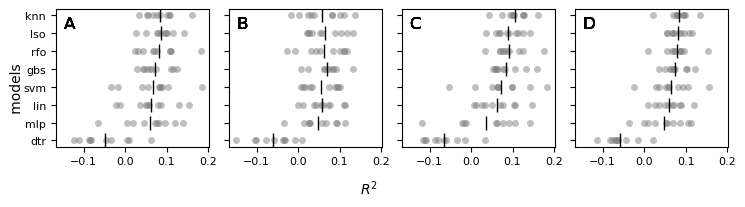

In [28]:
# figure settings and formats
fs_ytlab=8
fs_xtlab=8
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*14/14
fig_height_cm=5
ms_cv=5
ms_cv_mean=2*ms_cv
fig_dpi=600



#determine which metric to plot
metric='r2'
metric_label=r'$R^2$'

# determine order of models in y-axis, based on the mean label scores
mean_label_scores=[results[m][f'mean_test_{metric}'] for m in models]
sort_indices=np.argsort(mean_label_scores)
sorted_models=[models[i] for i in sort_indices]

# initialize figure
plt.close("all")
fig,axes=plt.subplots(nrows=1,ncols=len(label_scores),figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharey=True,sharex=True)
sp_label=['A','B','C','D']
# loop through sorted models
for sm, smodel in enumerate(sorted_models):
    # loop through label scores and figure axes
    for l,label in enumerate(label_scores):
        # get data to plot
        if 'mean' not in label:
            cv_scores=np.vstack(results[smodel][f'per_target_{metric}'])[:,l]
            mean_cv_score=np.mean(np.vstack(results[smodel][f'per_target_{metric}'])[:,l])
        else:
            cv_scores=results[smodel][f'test_{metric}']
            mean_cv_score=results[smodel][f'mean_test_{metric}']
        # plot data
        axes[l].plot(cv_scores,sm*np.ones(len(cv_scores)),'o',lw=0, mfc='0.5', alpha=0.5,mew=0,ms=ms_cv)
        axes[l].plot(mean_cv_score,sm,'k|',lw=2,ms=ms_cv_mean,mew=1)

        # set xticklabel fontsize
        axes[l].tick_params(labelsize=fs_xtlab)
        
        # add subplot label
        axes[l].text(0.05,0.95,sp_label[l],ha='left',va='top',fontsize=fs_annot,transform=axes[l].transAxes)

# rename y-axis tick labels
axes[0].set_yticks(np.arange(len(models)))
axes[0].set_yticklabels(sorted_models,fontsize=fs_ytlab)

# add x-axis label
fig.supxlabel(metric_label,fontsize=fs_xlab)
fig.supylabel('      models',fontsize=fs_xlab)
fig.tight_layout(pad=0.5)
fig.savefig(f'{filename.split(".")[0]}-generalized-{metric}.jpg',dpi=fig_dpi)
fig.savefig(f'{filename.split(".")[0]}-generalized-{metric}.svg')
# plt.close("all")


## Performance on unseen test set

In [29]:
# define input file path for features and labels
data_dir2 = Path.cwd().parent / "outputs" / "features"
filename2="features-all-abdda36.pkl"
input_file_path2 = data_dir2 / filename2

# read pickle file
with open(input_file_path2, "rb") as f:  # "rb" means Read Binary
    features_df = pickle.load(f)


In [30]:
test_idx=results['_meta']['test_idx']
features_df.loc[test_idx]
features=results['_meta']['feature_names']
labels=results['_meta']['label_names']

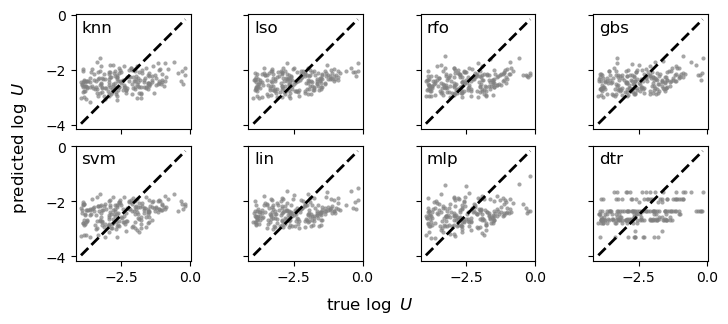

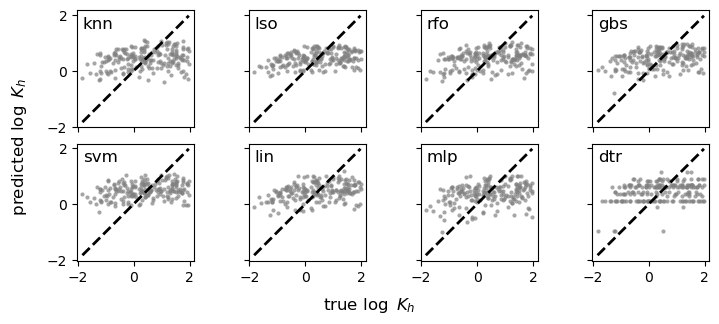

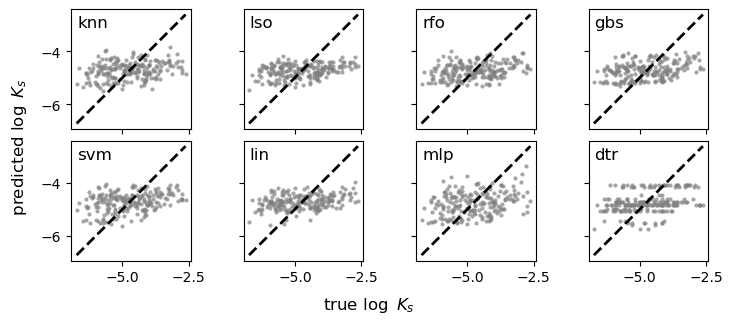

In [32]:
# figure settings and formats
fs_ytlab=8
fs_xtlab=8
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*14/14
fig_height_cm=8
ms=3
malpha=0.7
fig_dpi=600



plt.close("all")

fig1,axes1=plt.subplots(nrows=2,ncols=int(len(models)/2),figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)
fig2,axes2=plt.subplots(nrows=2,ncols=int(len(models)/2),figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)
axes1=axes1.flatten()
axes2=axes2.flatten()

if len(labels)>2:
    fig3,axes3=plt.subplots(nrows=2,ncols=int(len(models)/2),figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=True,sharey=True)
    axes3=axes3.flatten()


for m,model in enumerate(sorted_models[::-1]):
    rgr=results[model]['final_model']['regressor']
    ypred=rgr.predict(features_df.loc[test_idx,features])
    ytrue=features_df.loc[test_idx,labels]
    axes1[m].plot(np.log10(ytrue.loc[:,labels[0]]),ypred[:,0],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    axes1[m].plot([np.min(np.log10(ytrue.loc[:,labels[0]])),np.max(np.log10(ytrue.loc[:,labels[0]]))],
                  [np.min(np.log10(ytrue.loc[:,labels[0]])),np.max(np.log10(ytrue.loc[:,labels[0]]))],
                  ls='--',c='k',lw=2)
    axes1[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes1[m].transAxes)
    axes1[m].axis('scaled')
    
    axes2[m].plot(np.log10(ytrue.loc[:,labels[1]]),ypred[:,1],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
    axes2[m].plot([np.min(np.log10(ytrue.loc[:,labels[1]])),np.max(np.log10(ytrue.loc[:,labels[1]]))],
                  [np.min(np.log10(ytrue.loc[:,labels[1]])),np.max(np.log10(ytrue.loc[:,labels[1]]))],
                  ls='--',c='k',lw=2)
    axes2[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes2[m].transAxes)
    axes2[m].axis('scaled')
    if len(labels)>2:
        axes3[m].plot(np.log10(ytrue.loc[:,labels[2]]),ypred[:,2],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
        axes3[m].plot([np.min(np.log10(ytrue.loc[:,labels[2]])),np.max(np.log10(ytrue.loc[:,labels[2]]))],
                      [np.min(np.log10(ytrue.loc[:,labels[2]])),np.max(np.log10(ytrue.loc[:,labels[2]]))],
                      ls='--',c='k',lw=2)
        axes3[m].text(0.05,0.95,model,ha='left',va='top',fontsize=fs_annot,transform=axes3[m].transAxes)
        axes3[m].axis('scaled')

fig1.supxlabel(fr'true $\log\ U$')
fig2.supxlabel(fr'true $\log\ K_h$')
fig1.supylabel(fr'     predicted $\log\ U$')
fig2.supylabel(fr'     predicted $\log\ K_h$')


# fig1.supxlabel(fr'true $\log\ U/K_s$')
# fig2.supxlabel(fr'true $\log\ K_h/K_s$')
# fig1.supylabel(fr'     predicted $\log\ U/K_s$')
# fig2.supylabel(fr'     predicted $\log\ K_h/K_s$')
if len(labels)>2:
    fig3.supxlabel(fr'true $\log\ K_s$')
    fig3.supylabel(fr'     predicted $\log\ K_s$')


fig2.tight_layout(pad=0.5)
fig1.tight_layout(pad=0.5)

fig1.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[0]}.jpg',dpi=fig_dpi)
fig1.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[0]}.svg')
fig2.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[1]}.jpg',dpi=fig_dpi)
fig2.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[1]}.svg')
if len(labels)>2:
    fig3.tight_layout(pad=0.5)
    fig3.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[2]}.jpg',dpi=fig_dpi)
    fig3.savefig(f'{filename.split(".")[0]}-unseen-test-set-{labels[2]}.svg')
    

## Combined Plots
A: Generalized performance ($R^2$) of models trained to estimate the individual LEM parameters, with $\texttt{knn}$ as the best model. Black vertical bars show the means of the individual cross validation fold scores (gray dots). $R^2$ for all models are less than 0.2.

B to D: Performance of the best model for estimating $\log\ U$, $\log\ K_h$, and $\log\ K_s$ for an unseen test set. Dashed line represents the 1:1 line, and shows that 

E: Generalized performance ($R^2$) of models trained to estimate the LEM parameter ratios, with $\texttt{mlp}$ as the best model. $R^2$ for all models are more than 0.9.

F to G: Performance of the best model for estimating $\log\ U/K_s$ and $\log\ K_h/K_s$$ for an unseen test set. 

In [2]:
def read_model_results(data_dir,filename):
    input_file_path = data_dir / filename
    with open(input_file_path, "rb") as f:  # "rb" means Read Binary
        results = pickle.load(f)
    
    # get list of models
    models=[m for m in list(results.keys()) if m[0]!="_"]
    # get list of metrics
    metrics=[m[5:] for m in list(results[list(results.keys())[0]].keys()) if m[:5]=='test_']
    # get list of labels
    labels=list(results['_meta']['label_names'])
    # get list of features
    features=results['_meta']['feature_names']
    # get test set indices
    test_idx=results['_meta']['test_idx']

    return results, models, metrics, labels, features, test_idx


def read_features(input_file_path):
    with open(input_file_path, "rb") as f:  # "rb" means Read Binary
        features_df = pickle.load(f)
    return features_df





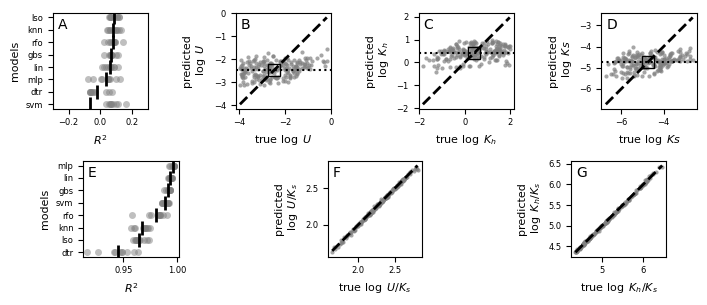

In [4]:
# figure settings and formats
PAGE_WIDTH_CM=19

fs_ytlab=6
fs_xtlab=6
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*19/19
fig_height_cm=8
ms_cv=5
ms_cv_mean=2*ms_cv
ms=3
malpha=0.7
fig_dpi=600



# SETUP FIGURE AND SUBPLOTS
fig = plt.figure(figsize=(fig_width_cm/2.54, fig_height_cm/2.54))
# GridSpec: 2 rows, 12 columns (LCM of 3 and 4)
gs = gridspec.GridSpec(2, 12, figure=fig)
# set top row to have 4 subplots
axt = [fig.add_subplot(gs[0, i*3:(i+1)*3]) for i in range(4)]
# set bottom row to have 3 subplots
axb = [fig.add_subplot(gs[1, i*4:(i+1)*4]) for i in range(3)]


# TOP ROW PLOTS ──────────────────────────
# read input file for model results (u, kh, and ks as labels)
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename="nested-cv-results-full-u-kh-ks-73a3f82.pkl"
results, models, metrics, labels, features, test_idx = read_model_results(data_dir,filename)
git_hash=results['_meta']['git_hash']
features_hash=results['_meta']['features_hash']
if features_hash==None:
    features_hash=filename.split("-")[-1].split(".")[0]

# read input file for features and labels
data_dir_features = Path.cwd().parent / "outputs" / "features"
filename_features=f"features-all-{features_hash}.pkl"
input_file_path = data_dir_features / filename_features
features_df=read_features(input_file_path)

#determine which metric to plot
metric='r2'
metric_label=r'$R^2$'

# determine order of models in y-axis, based on the mean label scores
mean_label_scores=[results[m][f'mean_test_{metric}'] for m in models]
sort_indices=np.argsort(mean_label_scores)
sorted_models=[models[i] for i in sort_indices]

sp_labels=['A','B','C','D']
# loop through sorted models
for sm, smodel in enumerate(sorted_models):
    # get data to plot
    cv_scores=results[smodel][f'test_{metric}']
    mean_cv_score=results[smodel][f'mean_test_{metric}']
    # plot data
    axt[0].plot(cv_scores,sm*np.ones(len(cv_scores)),'o',lw=0, mfc='0.5', alpha=0.5,mew=0,ms=ms_cv)
    axt[0].plot(mean_cv_score,sm,'k|',lw=2,ms=ms_cv_mean,mew=2)
    # add subplot label
    if sm==0:
        axt[0].text(0.05,0.95,sp_labels[0],ha='left',va='top',fontsize=fs_annot,transform=axt[0].transAxes)
axt[0].set_box_aspect(1)

# rename y-axis tick labels, add x-axis label
axt[0].set_yticks(np.arange(len(models)))
axt[0].set_yticklabels(sorted_models,fontsize=fs_ytlab)
axt[0].set_xlim(-.3,0.3)
axt[0].set_xticks([-.2,0,0.2])
axt[0].set_xlabel(metric_label,fontsize=fs_xlab)
axt[0].set_ylabel('models',fontsize=fs_xlab)
axt[0].tick_params(axis='x',labelsize=fs_xtlab)



ax_labels=[r'$\log\ U$',r'$\log\ K_h$',r'$\log\ Ks$']
for m,model in enumerate(sorted_models[::-1]):
    rgr=results[model]['final_model']['regressor']
    ypred=rgr.predict(features_df.loc[test_idx,features])
    ytrue=features_df.loc[test_idx,labels]
    
    for sp in range(1,len(axt)):
        axt[sp].plot(np.log10(ytrue.loc[:,labels[sp-1]]),ypred[:,sp-1],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
        
        axt[sp].plot([np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      [np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      ls='--',c='k',lw=2)
        mean_ytrue=np.mean(np.log10(ytrue.loc[:,labels[sp-1]]))
        axt[sp].plot(mean_ytrue,mean_ytrue,'ks',mfc='none',ms=8)
        axt[sp].axhline(y=mean_ytrue,ls=':',c='k')
        # axt[sp].axvline(x=mean_ytrue,ymax=mean_ytrue,ls='--',c='k')
        
        axt[sp].text(0.05,0.95,sp_labels[sp],ha='left',va='top',fontsize=fs_annot,transform=axt[sp].transAxes)
        axt[sp].set_xlabel('true '+ax_labels[sp-1],fontsize=fs_xlab)
        axt[sp].set_ylabel('predicted\n '+ax_labels[sp-1],fontsize=fs_xlab)
        axt[sp].axis('scaled')
        axt[sp].set_anchor('C')
        axt[sp].tick_params(labelsize=fs_xtlab)
        
    break




# BOTTOM ROW PLOTS ──────────────────────────
# read input file for model results (u/ks and kh/ks as labels)
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename=f"nested-cv-results-full-u_ks-kh_ks-{git_hash}.pkl"
results, models, metrics, labels, features, test_idx = read_model_results(data_dir,filename)


#determine which metric to plot
metric='r2'
metric_label=r'$R^2$'

# determine order of models in y-axis, based on the mean label scores
mean_label_scores=[results[m][f'mean_test_{metric}'] for m in models]
sort_indices=np.argsort(mean_label_scores)
sorted_models=[models[i] for i in sort_indices]

sp_labels=['E','F','G']

# loop through sorted models
for sm, smodel in enumerate(sorted_models):
    # get data to plot
    cv_scores=results[smodel][f'test_{metric}']
    mean_cv_score=results[smodel][f'mean_test_{metric}']
    # plot data
    axb[0].plot(cv_scores,sm*np.ones(len(cv_scores)),'o',lw=0, mfc='0.5', alpha=0.5,mew=0,ms=ms_cv)
    axb[0].plot(mean_cv_score,sm,'k|',lw=2,ms=ms_cv_mean,mew=2)
    # add subplot label
    if sm==0:
        axb[0].text(0.05,0.95,sp_labels[0],ha='left',va='top',fontsize=fs_annot,transform=axb[0].transAxes)
axb[0].set_box_aspect(1)

# rename y-axis tick labels, add x-axis label
axb[0].set_yticks(np.arange(len(models)))
axb[0].set_yticklabels(sorted_models,fontsize=fs_ytlab)
axb[0].set_xlabel(metric_label,fontsize=fs_xlab)
axb[0].set_ylabel('models',fontsize=fs_xlab)
axb[0].tick_params(axis='x',labelsize=fs_xtlab)


    
ax_labels=[r'$\log\ U/K_s$',r'$\log\ K_h/K_s$']
for m,model in enumerate(sorted_models[::-1]):
    rgr=results[model]['final_model']['regressor']
    ypred=rgr.predict(features_df.loc[test_idx,features])
    ytrue=features_df.loc[test_idx,labels]
    for sp in range(1,len(axb)):
        axb[sp].plot(np.log10(ytrue.loc[:,labels[sp-1]]),ypred[:,sp-1],marker='o',mfc='0.5',mew=0,lw=0,ms=ms,alpha=malpha)
        
        axb[sp].plot([np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      [np.min(np.log10(ytrue.loc[:,labels[sp-1]])),np.max(np.log10(ytrue.loc[:,labels[sp-1]]))],
                      ls='--',c='k',lw=2)
        
        axb[sp].text(0.05,0.95,sp_labels[sp],ha='left',va='top',fontsize=fs_annot,transform=axb[sp].transAxes)
        axb[sp].set_xlabel('true '+ax_labels[sp-1],fontsize=fs_xlab)
        axb[sp].set_ylabel('predicted\n '+ax_labels[sp-1],fontsize=fs_xlab)
        axb[sp].axis('scaled')
        # if sp==1:
            # axb[sp].set_anchor('C')
        # if sp==2:
            # axb[sp].set_anchor('W')
        axb[sp].tick_params(labelsize=fs_xtlab)
    break

fig.tight_layout(h_pad=1)
fig.savefig(f'{git_hash}/nested-cv-results-all-labels-generalized-and-unseen-test-set-{git_hash}.jpg',dpi=fig_dpi)
fig.savefig(f'{git_hash}/nested-cv-results-all-labels-generalized-and-unseen-test-set-{git_hash}-.svg')

In [10]:
results['_meta']

{'feature_names': ['Ly',
  'Z_mean',
  'Z_cv',
  'Z_med',
  'Z_max',
  'Z_skew',
  'Z_kurt',
  'grd_mean',
  'grd_std',
  'grd_med',
  'grd_max',
  'grd_skew',
  'grd_kurt',
  'crv_mean',
  'crv_std',
  'crv_min',
  'crv_med',
  'crv_max',
  'crv_skew',
  'crv_kurt',
  'htcrv_mean',
  'htcrv_std',
  'htcrv_min',
  'htcrv_med',
  'htcrv_max',
  'htcrv_skew',
  'htcrv_kurt',
  'hyp_int',
  'n_nodes',
  'Rb',
  'Rl',
  'Rb0',
  'Rl0',
  'n0',
  'L0',
  'l0_mean',
  'rlf0_mean',
  'grd0_mean',
  'path_max'],
 'label_names': ['u_ks', 'kh_ks'],
 'job_ids': ['121701',
  '121702',
  '121703',
  '121704',
  '121705',
  '121706',
  '121707',
  '121708',
  '121709',
  '121710',
  '121711',
  '121712',
  '121713',
  '121714',
  '121715',
  '121716',
  '121717',
  '121718',
  '121719',
  '121720',
  '121721',
  '121722',
  '121723',
  '121724',
  '121725',
  '122001',
  '122002',
  '122003',
  '122004',
  '122005',
  '122006',
  '122007',
  '122008',
  '122009',
  '122010',
  '122011',
  '122012',


# 04_FEATURE_IMPORTANCE FIGURES

In [5]:
# Define input file path to get the feature_hash
data_dir = Path.cwd().parent / "outputs" / "models" / "full-features"
filename="nested-cv-results-full-u-kh-ks-73a3f82.pkl"
input_file_path = data_dir / filename
# read pickle file
with open(input_file_path, "rb") as f:  # "rb" means Read Binary
    results = pickle.load(f)
features_hash=results['_meta']['features_hash']
if features_hash==None:
    features_hash=filename.split("-")[-1].split(".")[0]
git_hash=results['_meta']['git_hash']

In [6]:
# read input file for features and labels based on the feature_hash
data_dir2 = Path.cwd().parent / "outputs" / "features"
filename2=f"features-all-{features_hash}.pkl"
input_file_path2 = data_dir2 / filename2
with open(input_file_path2, "rb") as f:  # "rb" means Read Binary
    features_df = pickle.load(f)

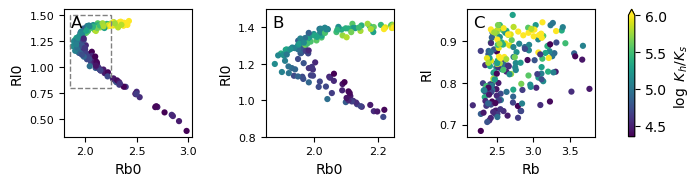

In [7]:
import matplotlib.patches as patches

PAGE_WIDTH_CM=19

fs_ytlab=8
fs_xtlab=8
fs_xlab=fs_xtlab+2
fs_annot=fs_xlab+2
fig_width_cm=PAGE_WIDTH_CM*19/19
fig_height_cm=5
ms_cv=5
ms_cv_mean=2*ms_cv
ms=20
malpha=0.7
fig_dpi=600


idx=results['_meta']['test_idx']
np.random.seed(None)
np.random.shuffle(idx)
vmax=6

sp_labels=['A','B','C']
a=0
fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(fig_width_cm/2.54,fig_height_cm/2.54),sharex=False,sharey=False)
ax[a].text(0.05,0.95,sp_labels[a],ha='left',va='top',fontsize=fs_annot,transform=ax[a].transAxes)
sc=ax[a].scatter(features_df.iloc[idx]['Rb0'],
              features_df.iloc[idx]['Rl0'],
              lw=0,marker='o',s=ms,
              c=np.log10(features_df.iloc[idx]['kh_ks']),vmax=vmax)
ax[a].tick_params(labelsize=fs_xtlab)
ax[a].set_xlabel('Rb0',fontsize=fs_xlab)
ax[a].set_ylabel('Rl0',fontsize=fs_xlab)
ur=(2.25,1.5)
ll=(1.85,0.8)
width=(ur[0]-ll[0])
height=(ur[1]-ll[1])
rect = patches.Rectangle(
    ll,
    width,
    height,
    linewidth=1,ls='--',
    edgecolor='0.5',  # Red border
    facecolor='none' # No fill color
)
ax[a].add_patch(rect)


a+=1
ax[a].text(0.05,0.95,sp_labels[a],ha='left',va='top',fontsize=fs_annot,transform=ax[a].transAxes)
sc=ax[a].scatter(features_df.iloc[idx]['Rb0'],
              features_df.iloc[idx]['Rl0'],
              lw=0,marker='o',s=ms,
              c=np.log10(features_df.iloc[idx]['kh_ks']),vmax=vmax)
ax[a].tick_params(labelsize=fs_xtlab)
ax[a].set_xlabel('Rb0',fontsize=fs_xlab)
ax[a].set_ylabel('Rl0',fontsize=fs_xlab)
# ur=(2.5,3)
# ll=(1.85,1.35)
ax[a].set_xlim(ll[0],ur[0])
ax[a].set_ylim(ll[1],ur[1])



a+=1
ax[a].text(0.05,0.95,sp_labels[a],ha='left',va='top',fontsize=fs_annot,transform=ax[a].transAxes)
sc=ax[a].scatter(features_df.iloc[idx]['Rb'],
              features_df.iloc[idx]['Rl'],
              lw=0,marker='o',s=ms,
              c=np.log10(features_df.iloc[idx]['kh_ks']),vmax=vmax)
ax[a].tick_params(labelsize=fs_xtlab)
ax[a].set_xlabel('Rb',fontsize=fs_xlab)
ax[a].set_ylabel('Rl',fontsize=fs_xlab)
fig.tight_layout(w_pad=3)
fig.colorbar(sc, ax=ax,extend='max',label=r'$\log\ K_h/K_s$')

# save figure in folder according to githash
git_hash='1982ab3'
fig.savefig(f'{git_hash}/nested-cv-results-Rb0-Rl0-feature-space-{features_hash}-{git_hash}.jpg',dpi=fig_dpi)
fig.savefig(f'{git_hash}/nested-cv-results-Rb0-Rl0-feature-space-{features_hash}-{git_hash}.svg')

In [8]:
import pandas as pd
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from collections import defaultdict
import os

DOMAIN_REDUCED_FEATURES = [
    'n0',          # zero-order channel count  — primary finding
    'Z_mean',      # mean elevation            — scaling
    'Z_cv',        # elevation variability     — relief organisation
    'Z_skew',      # elevation skewness        — hypsometry proxy
    'Rl',          # length ratio              — network geometry
    'htcrv_med',   # median hilltop curvature  — erosion-uplift balance
    'crv_mean',    # mean curvature            — overall curvature
    'crv_kurt',    # curvature kurtosis        — curvature heterogeneity
    'htcrv_min',   # minimum hilltop curvature — extreme curvature signal
    'htcrv_max',   # maximum hilltop curvature — extreme curvature signal
    'hyp_int',     # hypsometric integral      — landscape maturity
    'Rb',          # mean bifurcation ratio    — network structure
    'Rb0',         # zero-order bifurcation    — primary finding
    'Rl0',         # zero-order length ratio   — network geometry
]


fig_dpi=600


def get_feature_clusters(
    X: pd.DataFrame,
    feature_hash: str,
    dist_thresh: float = 0.25,
    output_dir: str = 'outputs',
    git_hash: str = 'latest',
    label_tag: str = '',
    feature_selection: str = 'domain',
    random_state: int = 42,
    fig_dpi=600,
) -> tuple:
    """Identify multicollinear feature clusters via hierarchical clustering.

    Uses Spearman rank correlation converted to a distance matrix, then
    Ward linkage.  Produces a dendrogram figure with selected features marked.

    Parameters
    ----------
    X : pd.DataFrame
        Full feature matrix (training set only).
    dist_thresh : float
        Distance threshold for cutting the dendrogram into clusters.
        Features within ``dist_thresh`` of each other are grouped.
    output_dir : str
    git_hash : str
    feature_selection : str
        ``'domain'`` — use ``DOMAIN_REDUCED_FEATURES`` (default).
        ``'random'`` — draw one random representative per cluster.
    random_state : int
        Seed for random representative selection (only used when
        ``feature_selection='random'``).

    Returns
    -------
    reduced_features : list of str
    cluster_id_to_feature_ids : dict
        Maps cluster ID → list of feature column indices within that cluster.
    """
    # Spearman correlation → distance matrix
    corr = spearmanr(X).correlation
    corr = (corr + corr.T) / 2
    np.fill_diagonal(corr, 1)
    distance_matrix = 1 - np.abs(corr)
    dist_linkage    = hierarchy.ward(squareform(distance_matrix))
    dist_linkage = np.where(dist_linkage<0.0001,0.0001, dist_linkage)

    # Dendrogram
    fig, ax = plt.subplots(figsize=(14 / 2.54, 8))
    dendro = hierarchy.dendrogram(
        dist_linkage,
        labels=X.columns.to_list(),
        ax=ax,
        leaf_rotation=360,
        orientation='right',
        color_threshold=dist_thresh,
    )
    ax.axvline(x=dist_thresh, ls='--', c='k', label='threshold distance')
    ax.set_xlabel('distance', fontsize=8)
    # ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim(-0.01,)

    # Cluster assignments
    cluster_ids = hierarchy.fcluster(dist_linkage, dist_thresh, criterion='distance')
    cluster_id_to_feature_ids = defaultdict(list)
    for idx, cid in enumerate(cluster_ids):
        cluster_id_to_feature_ids[cid].append(idx)

    # Select representative features
    if feature_selection == 'random':
        rng = np.random.default_rng(random_state)
        selected_idx = [
            int(rng.choice(v)) for v in cluster_id_to_feature_ids.values()
        ]
        reduced_features = [X.columns[s] for s in selected_idx]
        print(f"Data-driven selection ({len(reduced_features)} features): {reduced_features}")
    else:
        reduced_features = DOMAIN_REDUCED_FEATURES
        missing = [f for f in reduced_features if f not in X.columns]
        if missing:
            raise ValueError(
                f"DOMAIN_REDUCED_FEATURES contains columns not in X: {missing}"
            )
        print(f"Domain-driven selection ({len(reduced_features)} features): {reduced_features}")

    # Annotate dendrogram with selected features
    tick_labels = [item.get_text() for item in ax.get_yticklabels()]
    annotated   = [f'*{l}' if l in reduced_features else l for l in tick_labels]
    ax.set_yticklabels(annotated)
    ax.tick_params(axis='both', labelsize=8)
    # ax.set_xlim(0.0001,None)
    # plt.semilogx(nonpositive='clip')
    fig.tight_layout()
    stem = os.path.join(output_dir, f'feature-clustering-{features_hash}-{git_hash}')
    print(stem)
    fig.savefig(stem + '.jpg', dpi=fig_dpi)
    fig.savefig(stem + '.svg')
    plt.close(fig)

    print(ax.get_yticks())

    return reduced_features, cluster_id_to_feature_ids

output_dir=Path.cwd() / "1982ab3"
print(output_dir)
reduced_features, cluster_id_to_feature_ids=get_feature_clusters(features_df.iloc[results['_meta']['train_idx']][results['_meta']['feature_names']]
                      ,features_hash,dist_thresh=0.12,output_dir=output_dir,git_hash='1982ab3')

/home/oz/Git/landscape-evolution-ml-horton-fix/notebooks/1982ab3
Domain-driven selection (14 features): ['n0', 'Z_mean', 'Z_cv', 'Z_skew', 'Rl', 'htcrv_med', 'crv_mean', 'crv_kurt', 'htcrv_min', 'htcrv_max', 'hyp_int', 'Rb', 'Rb0', 'Rl0']
/home/oz/Git/landscape-evolution-ml-horton-fix/notebooks/1982ab3/feature-clustering-73a3f82-1982ab3
[  5  15  25  35  45  55  65  75  85  95 105 115 125 135 145 155 165 175
 185 195 205 215 225 235 245 255 265 275 285 295 305 315 325 335 345 355
 365 375 385]
